# EDA: 컬럼 간 상관관계 확인

본격적인 분석에 앞서, 타이타닉 데이터를 불러와 숫자로 다루기 쉽게 정리하고 컬럼들이 서로 어떤 관계를 가지는지 살펴봅니다.

### 데이터 불러오기와 정리

문자로 되어 있는 값을 숫자로 바꾸고, 분석에 쓰지 않을 컬럼(승객 번호·이름·티켓 번호·객실 번호)은 제거합니다.

- `Sex`: 남성 0, 여성 1
- `Embarked`(탑승 항구): S 1, C 2, Q 3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style("whitegrid")

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Titanic-Dataset.csv")

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 1, "C": 2, "Q": 3})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,2.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0


우선 데이터를 생각해 봤을 때 생존율에 영향을 줬을 것 같은 컬럼이 뭔지 생각해보고, 그 이유를 간단히 작성해 봅시다.

또, 생존율이 아니더라도 서로 연관이 있을 것으로 예상되는 컬럼 쌍을 생각해 봐도 좋습니다.

### 컬럼 간 상관관계 히트맵

**왜 볼까요?** 각 컬럼이 서로 얼마나 강하게 관련되어 있는지 한 눈에 확인하기 위한 것입니다. 값은 -1~1 사이이며, 1에 가까울수록 함께 커지는 관계, -1에 가까울수록 한쪽이 커질 때 다른 쪽이 작아지는 관계입니다. 0에 가까우면 뚜렷한 관계가 없다는 뜻입니다.

이 값은 두 컬럼이 함께 움직인다는 것을 보여줄 뿐, 한쪽이 다른 쪽의 원인이라는 뜻은 아닙니다.

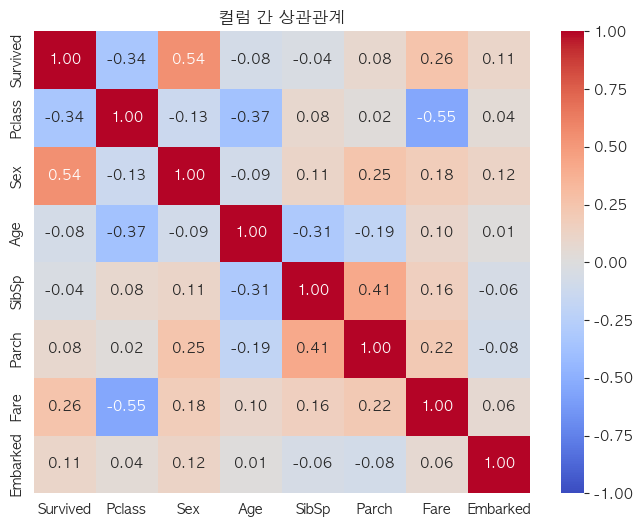

In [2]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("컬럼 간 상관관계")
plt.show()

히트맵을 보고 예상했던 결과와 일치하는지 확인합니다. 일치하지 않는다면 해당 정보에 대해서 좀 더 자세히 보면 됩니다. 만약 모두 일치한다면, 실제로 어떤 상관관계를 보이는지 직접 산점도를 그려 봅니다.

@"day1/4. 분류/3. XAI.ipynb" 코드를 먼저 읽어보고 변수 이름과 작성된 코드를 먼저 확인해봐. 그리고 내가 분석하고 싶은 것에 대한 코드를 작성해줘. 노트북을 직접 수정하진 말고 채팅에 코드를 작성해주면 내가 복사-붙여넣기 할게.

확인이 됐으면 이제 베이스라인 모델 학습을 수행해 봅니다.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df["Survived"]
X = df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X_train["Embarked"].median())

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"정확도: {accuracy:.3f}")

정확도: 0.804


Precision: 모델이 '생존'이라고 예측한 사람 중, 실제로 생존한 비율
Recall: 실제 생존자 중, 모델이 '생존'이라고 맞춘 비율

Precision: 0.793
Recall: 0.667
F1 score: 0.724
AUC: 0.843


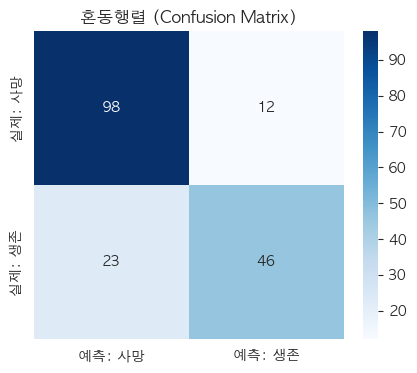

In [4]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # 생존(1)일 확률


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
# F1 score: Precision과 Recall의 조화평균 (두 지표를 함께 요약)
f1 = f1_score(y_test, y_pred)
# AUC: 생존 확률 예측이 실제 순서를 얼마나 잘 구분하는지 (0.5는 무작위 수준, 1에 가까울수록 좋음)
auc = roc_auc_score(y_test, y_proba)

print("Precision: 모델이 '생존'이라고 예측한 사람 중, 실제로 생존한 비율")
print("Recall: 실제 생존자 중, 모델이 '생존'이라고 맞춘 비율\n")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 score: {f1:.3f}")
print(f"AUC: {auc:.3f}")

# 혼동행렬: Precision·Recall이 어떤 값들로부터 계산됐는지 확인
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["예측: 사망", "예측: 생존"],
    yticklabels=["실제: 사망", "실제: 생존"],
)
plt.title("혼동행렬 (Confusion Matrix)")
plt.show()


모델이 어떤 변수를 주요하게 보고 있는지 SHAP 그래프를 그려서 확인해 보겠습니다.

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


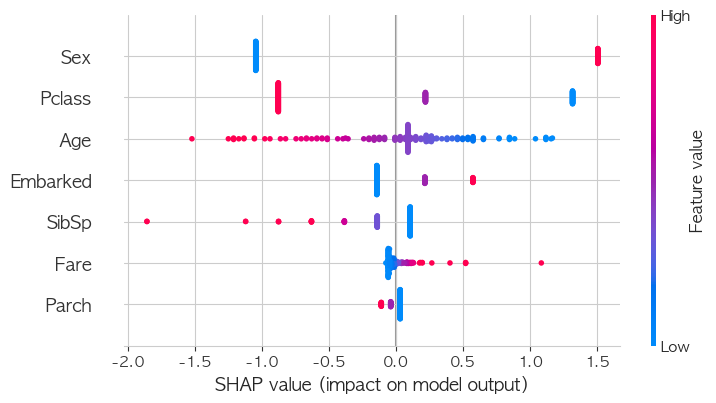

In [5]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# 한 줄 = 한 컬럼, 점 하나 = 승객 한 명
# 점 색: 빨강(값이 큼) ~ 파랑(값이 작음)
# x축(SHAP value): 그 승객의 예측을 '생존' 쪽(+)으로 밀었는지, '사망' 쪽(-)으로 밀었는지와 그 크기
shap.plots.beeswarm(shap_values)

SHAP은 기준 예측에서 각 항목이 예측을 얼마나 움직였는지 나누어 보여줍니다. **모델의 판단에 대한 설명이며 실제 생존·사망의 원인은 아닙니다.** 기준을 만들 때는 학습 자료만 사용하고, 평가 승객의 예측을 설명합니다.

- 아래 그래프의 점 하나는 해당 항목에 대한 승객 한 명의 기여도입니다. 세로로 퍼진 점은 겹침을 줄인 표시입니다.
- 가로축의 0보다 오른쪽은 생존 예측을 높이는 방향, 왼쪽은 낮추는 방향입니다.
- 색은 입력값의 크기입니다. 빨강은 큰 값, 파랑은 작은 값입니다. 성별은 여성=1이 빨강이며, 항구의 색은 숫자로 바꾼 항구 코드입니다.
- 위쪽 항목일수록 이 평가 자료에서 평균적인 기여의 크기가 큽니다. 중요하다는 이유만으로 오류 원인이라고 단정하지 않습니다.

가로축의 단위는 **로그 오즈**라는 모델 점수입니다. 확률의 %p가 아니므로, 승객별 생존 예측 확률은 별도 표에서 확인합니다.

그래프를 보고 처음 예상했던 결과와 일치하는지, 불일치하는지 확인합니다.

불일치 하는 부분이 있다면 해당 부분을 그래프로 확인합니다.

### 객실등급 X 성별 컬럼 추가하기

앞선 상관관계 히트맵을 보면 Survived와의 상관관계: Sex 0.54, Pclass -0.34로 둘 다 개별적으로 상관관계가 큰 편입니다.

그런데 Pclass와 Sex끼리의 상관관계는 -0.13으로 약합니다. 즉 "둘 다 생존과 관련이 크지만, 서로는 겹치는 정보가 별로 없다"는 뜻입니다.

그래서 "겹치지 않는 두 정보를 합쳤을 때 개별로 볼 때는 안 보이던 패턴(예: 특정 등급+성별 조합에서만 생존율이 유난히 높거나 낮은지)이 드러나는지 확인해보려고 합니다.

In [6]:
# 1. 객실등급(Pclass) x 성별(Sex) 조합 컬럼 추가
df["Pclass_Sex"] = df["Pclass"].astype(str) + "_" + df["Sex"].astype(str)
df = pd.get_dummies(df, columns=["Pclass_Sex"], dtype=int)

# 2. 새 컬럼이 포함된 데이터로 다시 나누고, 이전과 같은 방식으로 결측치 처리
y = df["Survived"]
X = df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X_train["Embarked"].median())

# 3. 학습 (기존 model 변수는 비교를 위해 남겨두고, 새 모델은 별도 이름으로)
model_v2 = LogisticRegression(random_state=42, max_iter=1000)
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)
y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

accuracy_v2 = model_v2.score(X_test, y_test)
precision_v2 = precision_score(y_test, y_pred_v2)
recall_v2 = recall_score(y_test, y_pred_v2)
f1_v2 = f1_score(y_test, y_pred_v2)
auc_v2 = roc_auc_score(y_test, y_proba_v2)

# 4. 이전 모델(model)과 지표 비교
print(f"{'지표':10s} {'기존 모델':>10s} {'컬럼 추가 후':>12s}")
print(f"{'Accuracy':10s} {accuracy:10.3f} {accuracy_v2:12.3f}")
print(f"{'Precision':10s} {precision:10.3f} {precision_v2:12.3f}")
print(f"{'Recall':10s} {recall:10.3f} {recall_v2:12.3f}")
print(f"{'F1 score':10s} {f1:10.3f} {f1_v2:12.3f}")
print(f"{'AUC':10s} {auc:10.3f} {auc_v2:12.3f}")

지표              기존 모델      컬럼 추가 후
Accuracy        0.804        0.810
Precision       0.793        0.857
Recall          0.667        0.609
F1 score        0.724        0.712
AUC             0.843        0.849


Precision 수치가 크게 증가한 것을 볼 수 있습니다. 한 번 shap 그래프도 그려 볼까요?

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


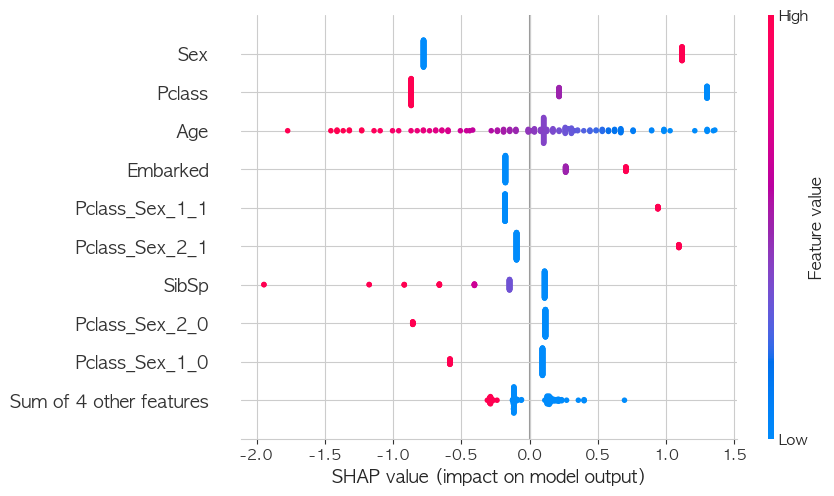

In [7]:
explainer_v2 = shap.Explainer(model_v2, X_train)
shap_values_v2 = explainer_v2(X_test)

shap.plots.beeswarm(shap_values_v2)

### 정보 추출하기

우리가 버렸던 컬럼 중 Name 컬럼을 보면 Mr, Mrs, Miss 같은 호칭이 들어 있습니다. 이 호칭을 뽑아서 새로운 컬럼으로 추가해서 학습을 진행해 봅니다.

### 나이 구간화

Age 컬럼을 몇 개 구간으로 나누면 SHAP에서 본 나이의 영향이 더 뚜렷해 지는지 직접 확인해 봅니다.